In [52]:
import datetime

import numpy as np
import pandas as pd
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [53]:
dataset = pd.read_csv("data/dataset.csv")
dataset_copy=dataset.copy()
dataset.head(5)

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [54]:
dataset=dataset[['Name', 'Location', 'Year', 'Kilometers_Driven',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power',
       'Seats', 'New_Price', 'Price']]

In [55]:
dataset['Manufacturer']=[i.split(" ")[0].lower() for i in dataset['Name']]

In [56]:
dataset['Mileage_Num'] = dataset['Mileage'].str.extract(r'(\d+\.\d+|\d+)', expand=True)
dataset['Mileage_Num']=dataset['Mileage_Num'].astype(float)
dataset["Mileage_Num"].fillna(dataset['Mileage_Num'].mode()[0],inplace=True)

In [57]:
dataset['Engine_Num'] = dataset['Engine'].str.extract(r'(\d+\.\d+|\d+)', expand=True)
dataset['Engine_Num']=dataset['Engine_Num'].astype(float)
dataset["Engine_Num"].fillna(dataset['Engine_Num'].mode()[0],inplace=True)

In [58]:
dataset['Power_Num'] = dataset['Power'].str.extract(r'(\d+\.\d+|\d+)', expand=True)
dataset['Power_Num']=dataset['Power_Num'].astype(float)
dataset["Power_Num"].fillna(dataset['Power_Num'].mode()[0],inplace=True)

In [59]:
dataset["Seats"].fillna(dataset['Seats'].mode()[0],inplace=True)

In [60]:
def create_dict(val_list,start_value):
    temp_dict=dict()
    val_list=set(val_list)
    for i in val_list:
        temp_dict[i]=start_value
        start_value+=1
    rev_temp_dict=dict(zip(temp_dict.values(),temp_dict.keys()))
    return temp_dict,rev_temp_dict   

In [61]:
manufacturer_dict,rev_manufacturer_dict=create_dict(dataset['Manufacturer'].unique(),0)
fuel_dict,rev_fuel_dict=create_dict(dataset['Fuel_Type'].unique(),0)
transmission_dict,rev_transmission_dict=create_dict(dataset['Transmission'].unique(),0) 
Owner_Type_dict,rev_Owner_Type_dict=create_dict(dataset['Owner_Type'].unique(),0) 

In [62]:
# for i in dataset.columns:
#     print(i,dataset[i].unique())

In [63]:
dataset_copy2=dataset.copy()

In [64]:
dataset=dataset[['Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Manufacturer', 'Mileage_Num', 'Engine_Num',
       'Power_Num','Price']]

Text(0, 0.5, 'Count of cars')

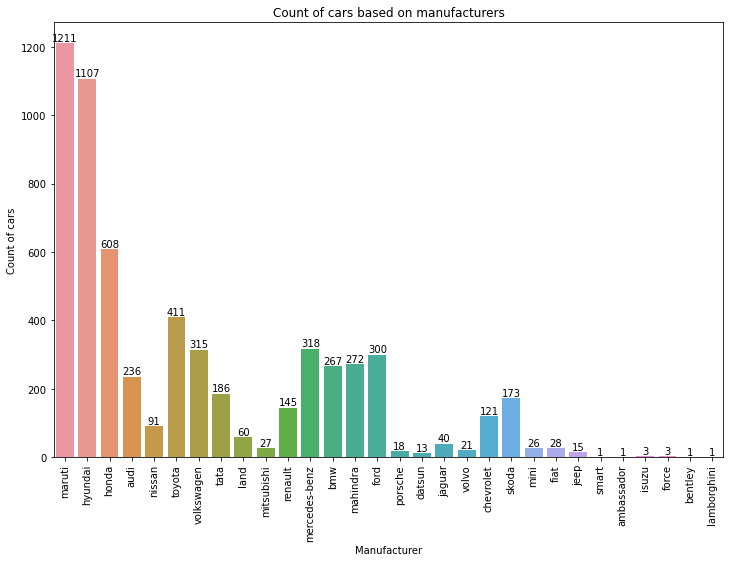

In [65]:
plt.figure(figsize = (12, 8))
plot = sns.countplot(x = 'Manufacturer', data = dataset)
plt.xticks(rotation = 90)
for p in plot.patches:
    plot.annotate(p.get_height(),
                        (p.get_x() + p.get_width() / 2.0,
                         p.get_height()),
                        ha = 'center',
                        va = 'center',
                        xytext = (0, 5),
                        textcoords = 'offset points')

plt.title("Count of cars based on manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Count of cars")

In [66]:
X=dataset[['Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type',  'Seats', 'Manufacturer', 'Mileage_Num', 'Engine_Num',
       'Power_Num']]
cols=['Manufacturer','Fuel_Type','Transmission','Owner_Type']
dicts=[manufacturer_dict,fuel_dict,transmission_dict,Owner_Type_dict]
for i in range(len(cols)):
    X[cols[i]]=X[cols[i]].replace(dicts[i])
    
y=dataset['Price']

C:\Users\manjunath.rs\AppData\Local\Temp\ipykernel_23980\2555213547.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cols[i]]=X[cols[i]].replace(dicts[i])


In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.3,
                                                    random_state = 24)

In [68]:
Owner_Type_dict.keys()

dict_keys(['First', 'Third', 'Second', 'Fourth & Above'])

In [70]:
X_train.describe()

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,Manufacturer,Mileage_Num,Engine_Num,Power_Num
count,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000
mean,2013.387372,57780.003086,1.450510,0.291716,0.343935,5.279136,15.499644,18.110465,1626.713743,112.598867
std,3.245269,39043.258783,0.516796,0.454606,0.745139,0.812961,6.565819,4.595211,606.438705,53.657589
min,1998.000000,171.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,624.000000,34.200000
25%,2011.000000,33485.000000,1.000000,0.000000,0.000000,5.000000,9.000000,15.150000,1197.000000,74.000000
50%,2014.000000,53000.000000,1.000000,0.000000,0.000000,5.000000,16.000000,18.100000,1493.000000,91.100000
75%,2016.000000,73053.000000,2.000000,1.000000,0.000000,5.000000,22.000000,21.100000,1991.000000,138.100000
max,2019.000000,775000.000000,4.000000,1.000000,3.000000,10.000000,29.000000,33.540000,5998.000000,552.000000


In [71]:
standardScaler = StandardScaler()
standardScaler.fit(X_train)
X_train = standardScaler.transform(X_train)
X_test = standardScaler.transform(X_test)

linearRegression = LinearRegression()
linearRegression.fit(X_train, y_train)
y_pred = linearRegression.predict(X_test)
print(r2_score(y_test, y_pred))

rf = RandomForestRegressor(n_estimators = 100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
r2_score(y_test, y_pred)


0.5826365052655944


0.8877751656541725

In [72]:
sampl=standardScaler.transform([X.values[4]])
rf.predict(sampl)

C:\Users\manjunath.rs\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([15.54875])

In [74]:
# import pickle
# with open('standardscaler.pickle', 'wb') as handle:
#     pickle.dump(standardScaler,handle)
# # save the model to disk
# filename = 'RandomForest.sav'
# pickle.dump(rf, open(filename, 'wb'))

# dump(rf, "RandomForest.joblib")

# import pickle
# with open('count.pickle', 'rb') as handle:
#     count = pickle.load(handle)

# with open('MultinomialNB.sav', 'rb') as handle:
#     language_detect_model = pickle.load(handle)

['RandomForest.joblib']

In [79]:
dump(rf, "RandomForest.joblib")
dump(standardScaler, "StandScaler.joblib")

['StandScaler.joblib']